# Pupil Energy Analysis

This notebook demonstrates how to calculate object-field energy captured between an inner and outer numerical aperture, plot the pupil-plane energy distribution, and calculate the radial pupil energy density.

Conventions used here:

- `mat` is the object-plane complex field amplitude matrix.
- `pixelSize` is the sample spacing in um.
- `lambda_` is the wavelength in um. Python reserves `lambda`, so the code uses `lambda_`.
- Pupil radius is expressed in NA units: `r = lambda_ * sqrt(fx**2 + fy**2)`.
- Pupil sample energy is scaled as `abs(FFT(mat))**2 * pixelSize**2 / mat.size`, so the total pupil energy equals `sum(abs(mat)**2) * pixelSize**2`.
- The normalized radial density `rho(r)` satisfies `rho(r) * dr = energy fraction in [r, r + dr]`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / "src"))

from fourier_optics import (
    calculate_pupil_energy,
    plot_pupil_energy_distribution,
    plot_radial_pupil_energy_density,
    pupil_energy_distribution,
    pupil_na_grid,
    radial_pupil_energy_density,
)

## Function Definitions

The package functions are imported above. Their implementations are shown here for notebook-local review and reuse.

In [2]:
def notebook_pupil_na_grid(shape, pixelSize, lambda_):
    rows, cols = shape
    fy = np.fft.fftshift(np.fft.fftfreq(rows, d=pixelSize))
    fx = np.fft.fftshift(np.fft.fftfreq(cols, d=pixelSize))
    na_x, na_y = np.meshgrid(lambda_ * fx, lambda_ * fy)
    return na_x, na_y, np.hypot(na_x, na_y)


def notebook_pupil_energy_distribution(mat, pixelSize):
    field = np.asarray(mat, dtype=np.complex128)
    spectrum = np.fft.fftshift(np.fft.fft2(field))
    return np.abs(spectrum) ** 2 * pixelSize**2 / field.size


def notebook_calculate_pupil_energy(mat, pixelSize, NAin, NAout, lambda_):
    energy = notebook_pupil_energy_distribution(mat, pixelSize)
    _, _, radius = notebook_pupil_na_grid(energy.shape, pixelSize, lambda_)
    mask = (radius >= NAin) & (radius <= NAout)
    return float(energy[mask].sum())


def notebook_radial_pupil_energy_density(mat, pixelSize, lambda_, bins=None, normalize=True):
    energy = notebook_pupil_energy_distribution(mat, pixelSize)
    _, _, radius = notebook_pupil_na_grid(energy.shape, pixelSize, lambda_)

    if bins is None:
        rows, cols = energy.shape
        dna_y = lambda_ / (rows * pixelSize)
        dna_x = lambda_ / (cols * pixelSize)
        max_radius = float(np.nanmax(radius))
        bin_count = max(1, int(np.ceil(max_radius / min(dna_x, dna_y))))
        bin_edges = np.linspace(0.0, max_radius, bin_count + 1)
    elif np.isscalar(bins):
        bin_edges = np.linspace(0.0, float(np.nanmax(radius)), int(bins) + 1)
    else:
        bin_edges = np.asarray(bins, dtype=np.float64)

    shell_energy, edges = np.histogram(radius.ravel(), bins=bin_edges, weights=energy.ravel())
    widths = np.diff(edges)
    density = shell_energy / widths
    if normalize:
        total = shell_energy.sum()
        if total > 0:
            density = density / total
    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, density

## Verification Fields

A constant field has only zero-NA energy. A phase-ramp field has energy concentrated at the spatial frequency set by the ramp.

In [3]:
pixelSize = 1.0  # um
lambda_ = 1.0  # um
shape = (128, 128)

constant_field = np.ones(shape, dtype=np.complex128)

cols = shape[1]
x = np.arange(cols)
order = 12
ramp_field = np.tile(np.exp(2j * np.pi * order * x / cols), (shape[0], 1))
expected_ramp_na = lambda_ * order / (cols * pixelSize)

print(f"Expected ramp NA: {expected_ramp_na:.6f}")

Expected ramp NA: 0.093750


## Energy Checks

In [4]:
constant_object_energy = np.sum(np.abs(constant_field) ** 2) * pixelSize**2
constant_pupil_energy = pupil_energy_distribution(constant_field, pixelSize).sum()
constant_captured_energy = calculate_pupil_energy(
    constant_field, pixelSize, NAin=0.0, NAout=0.01, lambda_=lambda_
)

ramp_object_energy = np.sum(np.abs(ramp_field) ** 2) * pixelSize**2
ramp_pupil_energy = pupil_energy_distribution(ramp_field, pixelSize).sum()
ramp_captured_energy = calculate_pupil_energy(
    ramp_field,
    pixelSize,
    NAin=expected_ramp_na - 0.002,
    NAout=expected_ramp_na + 0.002,
    lambda_=lambda_,
)

print(f"Constant object energy:        {constant_object_energy:.6f}")
print(f"Constant total pupil energy:   {constant_pupil_energy:.6f}")
print(f"Constant captured near NA=0:   {constant_captured_energy:.6f}")
print(f"Ramp object energy:            {ramp_object_energy:.6f}")
print(f"Ramp total pupil energy:       {ramp_pupil_energy:.6f}")
print(f"Ramp captured near target NA:  {ramp_captured_energy:.6f}")

assert np.isclose(constant_pupil_energy, constant_object_energy)
assert np.isclose(constant_captured_energy, constant_object_energy)
assert np.isclose(ramp_pupil_energy, ramp_object_energy)
assert np.isclose(ramp_captured_energy, ramp_object_energy)

Constant object energy:        16384.000000
Constant total pupil energy:   16384.000000
Constant captured near NA=0:   16384.000000
Ramp object energy:            16384.000000
Ramp total pupil energy:       16384.000000
Ramp captured near target NA:  16384.000000


## Pupil Energy Plot

The blue circle marks `NAin`; the magenta circle marks `NAout`. The display window is controlled by `maxNA`.

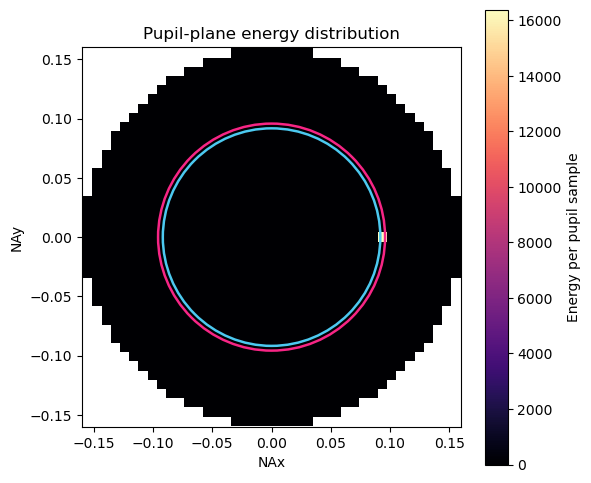

In [5]:
fig, ax = plt.subplots(figsize=(6.0, 5.2))
plot_pupil_energy_distribution(
    ramp_field,
    pixelSize=pixelSize,
    NAin=expected_ramp_na - 0.002,
    NAout=expected_ramp_na + 0.002,
    lambda_=lambda_,
    maxNA=0.16,
    ax=ax,
)
fig.tight_layout()
plt.show()

## Radial Energy Density

For normalized density, the discrete approximation to `integral rho(r) dr` should be 1 over the sampled NA range.

Integral of normalized radial density: 1.000000000000


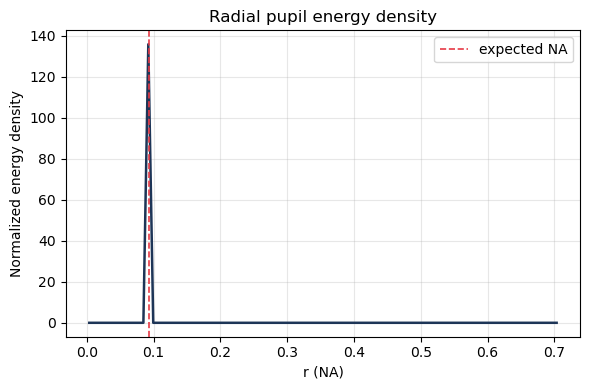

In [6]:
r, rho = radial_pupil_energy_density(ramp_field, pixelSize, lambda_, bins=96, normalize=True)
dr = r[1] - r[0]
print(f"Integral of normalized radial density: {np.sum(rho * dr):.12f}")
assert np.isclose(np.sum(rho * dr), 1.0)

fig, ax = plt.subplots(figsize=(6.0, 4.0))
plot_radial_pupil_energy_density(
    ramp_field,
    pixelSize=pixelSize,
    lambda_=lambda_,
    bins=96,
    normalize=True,
    ax=ax,
)
ax.axvline(expected_ramp_na, color="#e63946", linestyle="--", linewidth=1.2, label="expected NA")
ax.legend()
fig.tight_layout()
plt.show()

## Direct Use Example

In [7]:
energy_between_na = calculate_pupil_energy(
    ramp_field,
    pixelSize=pixelSize,
    NAin=0.08,
    NAout=0.11,
    lambda_=lambda_,
)
print(f"Energy between NA 0.08 and 0.11: {energy_between_na:.6f}")

Energy between NA 0.08 and 0.11: 16384.000000
